In [1]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from tqdm import tqdm
import matplotlib.pyplot as plt

In [2]:
DEVICE = torch.device("mps")

In [3]:
def calc_manual(l, h, x = 65):
    total = 0
    
    # Layer 0
    total += x * h * 4 # W_x
    total += h * h * 4 # W_h
    total += h * 8 # B_x + B_h
    
    for _ in range(l - 1):
        total += h * h * 4 # W_x
        total += h * h * 4 # W_h
        total += h * 8 # B_x + B_h
        
    return total

## Compute param counts - a test
for layers in [1, 2]:
    for hidden in [128, 256, 512]:
        model = nn.LSTM(65, hidden, layers)
        total = sum(p.numel() for p in model.parameters())
        print(f'Layers: {layers} | Hidden {hidden} | Total: {total}')
        print(f"Manua; total: {calc_manual(layers, hidden)}")
        
65 * 128 * 4 + 128 * 128 * 4 + 128 * 8
65 * 256 * 4 + 256 ** 2 * 4 + 256 * 8


Layers: 1 | Hidden 128 | Total: 99840
Manua; total: 99840
Layers: 1 | Hidden 256 | Total: 330752
Manua; total: 330752
Layers: 1 | Hidden 512 | Total: 1185792
Manua; total: 1185792
Layers: 2 | Hidden 128 | Total: 231936
Manua; total: 231936
Layers: 2 | Hidden 256 | Total: 857088
Manua; total: 857088
Layers: 2 | Hidden 512 | Total: 3287040
Manua; total: 3287040


330752

In [4]:
# Inspect the txt file
with open("data/tinyshakespeare.txt") as f:
    data = f.read()
    
    
## TEMP ##
# let's cut down data so we can quickly test
# data = data[:2048]
## END TEMP ##

print(len(data))
tokens = list(set(data))
print(len(tokens))

c2i = {c: i for i, c in enumerate(tokens)}
i2c = {i: c for c, i in c2i.items()}

TRAIN_PCT = 0.9
SPLIT_IDX = int(len(data) * TRAIN_PCT)

1115393
65


In [5]:
class TSDataset(Dataset):
    
    def __init__(self, test: bool = False, num_ctx: int = 256, epoch_size: int = 4096):
        self.test = test
        self.num_ctx = num_ctx
        self.epoch_size = epoch_size # roughly len(data) // num_ctx: 2^20 / 2^8 = 4096
        
        if self.test:
            self.data = data[SPLIT_IDX:]
        else:
            self.data = data[:SPLIT_IDX]
        
    def __len__(self):
        return self.epoch_size
        
    
    def __getitem__(self, _):
        start_idx = torch.randint(0, len(self.data) - self.num_ctx, (1,))
        seq_char = self.data[start_idx:start_idx + self.num_ctx]
        seq = torch.tensor([c2i[c] for c in seq_char])
        x = seq[:-1]
        y = seq[1:]
        return x, y

ds_train = TSDataset(test=False)
ds_test = TSDataset(test=True)
dl_train = DataLoader(ds_train, batch_size=16)
dl_test = DataLoader(ds_test, batch_size=16)

In [6]:
class SLM(nn.Module):
    """Small Language Model"""
    def __init__(self, n_layer: int, n_hidden: int, vocab_size: int):
        super().__init__()
        self.n_layer = n_layer
        self.n_hidden = n_hidden
        self.vocab_size=vocab_size
        
        self.emb = nn.Embedding(num_embeddings=vocab_size, embedding_dim=8)
        self.lstm = nn.LSTM(
            input_size=8,
            hidden_size=n_hidden,
            num_layers=n_layer,
            batch_first=True
        )
        self.fc = nn.Linear(in_features=n_hidden, out_features=vocab_size)
    
    def forward(self, x):
        x_emb = self.emb(x)
        out, (h_n, c_n) = self.lstm(x_emb)
        return self.fc(out)

In [18]:
def get_test_loss(model, dl_test):
    loss_fn = nn.CrossEntropyLoss()
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for x, y in dl_test:
            x = x.to(DEVICE)
            y = y.to(DEVICE)

            y_pred = model.forward(x)
            # flatten over B, T
            y_pred = y_pred.flatten(0, 1)
            y = y.flatten(0, 1)
            loss = loss_fn(y_pred, y)
            total_loss += loss * x.size(0)
    avg_loss = (total_loss / len(dl_test.dataset)).item()
    return avg_loss


def train(
    model: nn.Module, dl_train: DataLoader, dl_test: DataLoader, n_epochs: int = 10
) -> tuple[list[float], list[float]]:
    """
    :return: train_losses, test_losses
    """
    optim = torch.optim.AdamW(params=model.parameters(), lr=1e-3)
    loss_fn = nn.CrossEntropyLoss()
    pbar = tqdm(range(n_epochs))
    model.train()
    train_losses = []
    test_losses = []
    for _ in pbar:
        total_loss = 0
        for x, y in dl_train:
            x = x.to(DEVICE)
            y = y.to(DEVICE)

            optim.zero_grad()
            y_pred = model.forward(x)

            # flatten over B, T
            y_pred = y_pred.flatten(0, 1)
            y = y.flatten(0, 1)

            loss = loss_fn(y_pred, y)
            loss.backward()
            optim.step()

            total_loss += loss.detach() * x.size(0)

        avg_loss = (total_loss / len(dl_train.dataset)).item()
        train_losses.append(avg_loss)
        test_loss = get_test_loss(model, dl_test)
        test_losses.append(test_loss)
        pbar.set_postfix({"Train loss": avg_loss})

    return train_losses, test_losses

100%|██████████| 10/10 [00:33<00:00,  3.34s/it, Train loss=1.8]


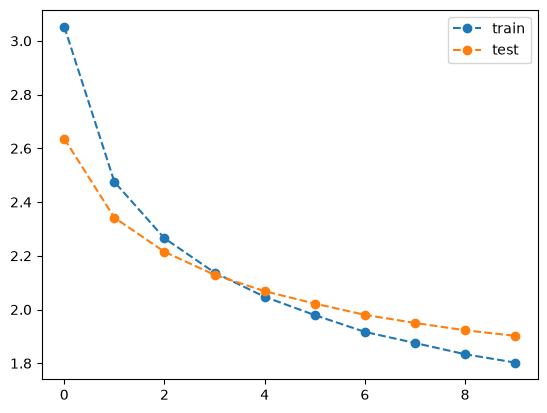

In [19]:
# Give it a whirl!

model = SLM(1, 128, len(tokens)).to(DEVICE)
train_losses, test_losses = train(model, dl_train, dl_test)

plt.plot(train_losses, "--o", label="train")
plt.plot(test_losses, "--o", label="test")
plt.legend()
plt.show()

## Let's conduct a sweep over model options and see what happens

```
Training n_hidden=128, n_layer=1
100%|██████████| 10/10 [00:33<00:00,  3.32s/it, Train loss=1.81]
Training n_hidden=128, n_layer=2
100%|██████████| 10/10 [01:01<00:00,  6.16s/it, Train loss=1.66]
Training n_hidden=256, n_layer=1
100%|██████████| 10/10 [00:43<00:00,  4.34s/it, Train loss=1.57]
Training n_hidden=256, n_layer=2
100%|██████████| 10/10 [01:23<00:00,  8.30s/it, Train loss=1.41]
Training n_hidden=512, n_layer=1
100%|██████████| 10/10 [01:16<00:00,  7.65s/it, Train loss=1.34]
Training n_hidden=512, n_layer=2
100%|██████████| 10/10 [02:34<00:00, 15.50s/it, Train loss=1.15]
```

In [20]:
n_hiddens = [128, 256, 512]
n_layers = [1, 2]

models = []
all_train_losses = []
all_test_losses = []
for n_hidden in n_hiddens:
    for n_layer in n_layers:
        print(f"Training n_hidden={n_hidden}, n_layer={n_layer}")
        model = SLM(n_layer, n_hidden, len(tokens)).to(DEVICE)
        train_losses, test_losses = train(model, dl_train, dl_test, n_epochs=10)
        all_train_losses.append(train_losses)
        all_test_losses.append(test_losses)
        models.append(model)

Training n_hidden=128, n_layer=1


100%|██████████| 10/10 [00:33<00:00,  3.32s/it, Train loss=1.81]


Training n_hidden=128, n_layer=2


100%|██████████| 10/10 [01:01<00:00,  6.16s/it, Train loss=1.66]


Training n_hidden=256, n_layer=1


...

100%|██████████| 10/10 [01:23<00:00,  8.30s/it, Train loss=1.41]


Training n_hidden=512, n_layer=1


100%|██████████| 10/10 [01:16<00:00,  7.65s/it, Train loss=1.34]


Training n_hidden=512, n_layer=2


100%|██████████| 10/10 [02:34<00:00, 15.50s/it, Train loss=1.15]


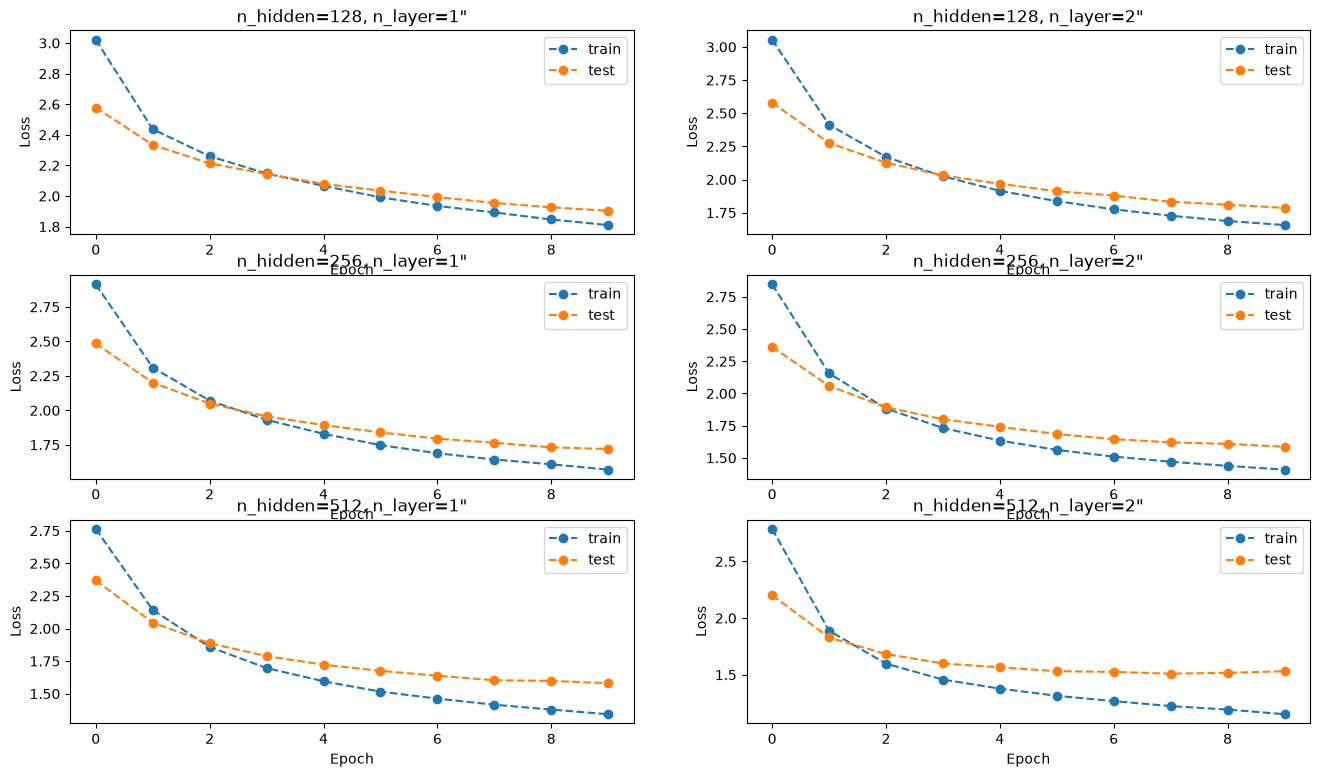

In [22]:
# Plot the results !?
fig, axs = plt.subplots(3, 2)
axs = axs.flatten()
for i, n_hidden in enumerate(n_hiddens):
    for j, n_layer in enumerate(n_layers):
        idx = i * 2 + j
        train_losses = all_train_losses[idx]
        test_losses = all_test_losses[idx]
        ax = axs[idx]
        
        ax.plot(train_losses, '--o', label='train')        
        ax.plot(test_losses, '--o', label='test')
        ax.set_ylabel("Loss")
        ax.set_xlabel("Epoch")
        ax.legend()
        ax.set_title(f'n_hidden={n_hidden}, n_layer={n_layer}"')

fig.set_size_inches(16, 9)
plt.show()

/var/folders/wf/jmjdzyf11pb4lsl77jc423840000gn/T/ipykernel_83013/3550909338.py:14: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


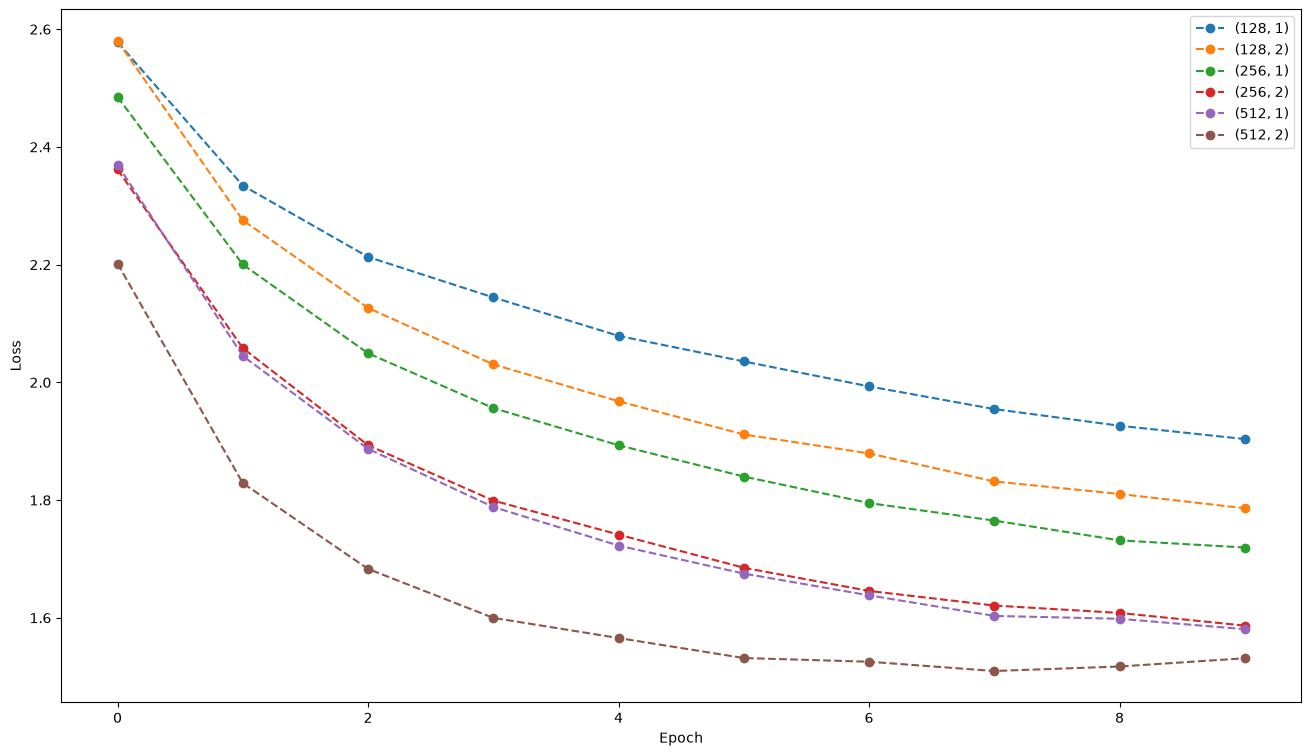

In [ ]:
## Now compares all test losses
## 
fig, ax = plt.subplots()
for i, n_hidden in enumerate(n_hiddens):
    for j, n_layer in enumerate(n_layers):
        idx = i * 2 + j
        test_losses = all_test_losses[idx]
        ax.plot(test_losses, "--o", label=f"({n_hidden}, {n_layer})")

ax.set_ylabel("Loss")
ax.set_xlabel("Epoch")
ax.legend()
fig.set_size_inches(16, 9)
fig.show()

Text(0, 0.5, 'Test Loss')

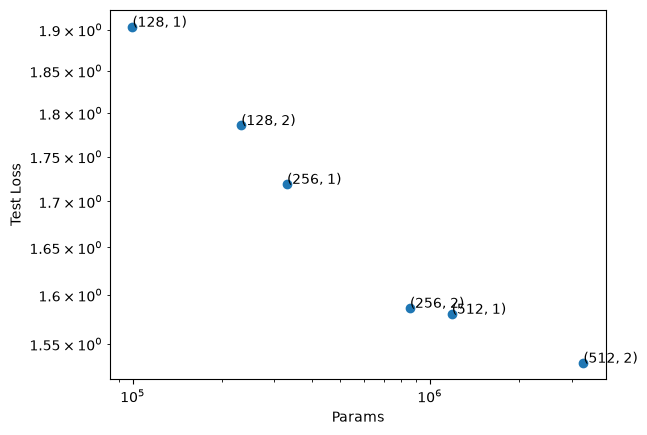

In [37]:
# What if we look at params vs. test loss?
# Some kind of power law relationship looks present.
params = []
final_test_losses = []
labels = []
for i, n_hidden in enumerate(n_hiddens):
    for j, n_layer in enumerate(n_layers):
        idx = i * 2 + j
        param_count = calc_manual(n_layer, n_hidden, x = len(tokens))
        params.append(param_count)
        final_test_losses.append(all_test_losses[idx][-1])
        labels.append(f'({n_hidden}, {n_layer})')
    

plt.scatter(params, final_test_losses)
for x, y, label in zip(params, final_test_losses, labels):
    plt.text(x, y, label)
plt.xscale('log')
plt.yscale('log')
plt.xlabel("Params")
plt.ylabel("Test Loss")

## Let's sample from the biggest baddest model now

In [90]:
def sample(model: SLM, prefix: str = "\n", seq_len: int = 256) -> str:
    # tokenize the prefix
    x = torch.tensor([c2i[c] for c in prefix]).to(DEVICE)

    chars = [c for c in prefix]
    model.eval()
    with torch.no_grad():
        for _ in range(seq_len - len(prefix)):
            y_pred = model.forward(x)
            logits = y_pred[-1, :]
            probs = logits.softmax(0)
            pred_idx = torch.multinomial(probs, 1).item()
            pred_char = i2c[pred_idx]
            chars.append(pred_char)
            
            # update x
            pred_token = torch.tensor([pred_idx]).to(DEVICE)
            x = torch.cat([x, pred_token])
            
    return "".join(chars)

def sample_cpu(model: SLM, prefix: str = "\n", seq_len: int = 256) -> str:
    # tokenize the prefix
    x = torch.tensor([c2i[c] for c in prefix])

    chars = [c for c in prefix]
    model.eval()
    with torch.no_grad():
        for _ in range(seq_len - len(prefix)):
            y_pred = model.forward(x)
            logits = y_pred[-1, :]
            probs = logits.softmax(0)
            pred_idx = torch.multinomial(probs, 1).item()
            pred_char = i2c[pred_idx]
            chars.append(pred_char)
            
            # update x
            pred_token = torch.tensor([pred_idx])
            x = torch.cat([x, pred_token])
            
    return "".join(chars)

In [91]:
model = models[-1]  # biggest
model_cpu = SLM(2, 512, 65)
model_cpu.load_state_dict(model.state_dict())

<All keys matched successfully>

In [95]:
generation = sample_cpu(model_cpu)
print(generation)



KING RICHARD III:
By no! he had a hopek, Henrymen yourself.

ROMEO:
Who seemed me pall to your captive scold;
He hopes ado.

CLAUDIO:
God save your ancasion! Duke of Lord Gullown
Makes Mabishrace pronounce bell me to death?
On my general souls, get thee 


In [94]:
generation = sample(model)
print(generation)



POLIXENES:
Nurse! From worth, we'll no hour crave?
Provoke? Aw, my lord, you peach left which?
Look, I should receives me in the common sudden:
And, as the easy to the pusting Comelit Warwick,
Whose, what loss of man will but will keep
Until your quarrel


## Done

We close here. Note the sampling is really quite inefficient as we don't persist (h_n, c_n). So instead of O(N), we are O(N^2)